# Brain Tumor MRI Classification - Exploratory Data Analysis

This notebook performs Exploratory Data Analysis (EDA) on the brain MRI scans. We analyze:
- Dataset splits and class balances
- Resolution distributions
- Visual sample grids for each tumor class
- Average intensity heatmaps per class


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from preprocessing import prepare_splits


## 1. Load Dataset Splits
We use our preprocessing pipeline to scan the `archive/` folder and prepare the clean splits.

In [2]:
train_df, val_df, test_df, le = prepare_splits('../archive')
train_df['split'] = 'Train'
val_df['split'] = 'Validation'
test_df['split'] = 'Test'
full_df = pd.concat([train_df, val_df, test_df])


Scanning dataset in: ../archive\Training



--- Image Scan Summary ---
Total Valid Images Found: 5429
Duplicates Detected & Removed: 171
Corrupted Images Detected & Removed: 0
Sample Duplicate: ../archive\Training\meningioma\Tr-me_1242.jpg is duplicate of ../archive\Training\meningioma\Tr-aug-me_90.jpg
Scanning dataset in: ../archive\Testing



--- Image Scan Summary ---
Total Valid Images Found: 1584
Duplicates Detected & Removed: 16
Corrupted Images Detected & Removed: 0
Sample Duplicate: ../archive\Testing\glioma\Te-gl_178.jpg is duplicate of ../archive\Testing\glioma\Te-gl_170.jpg

Data Splits:
Training set: 4614 samples
Validation set: 815 samples
Testing set: 1584 samples
Saved label_encoder.pkl to models/


## 2. Class Distribution Analysis
We analyze the count of images in each of the four categories across the splits to ensure they are representative.

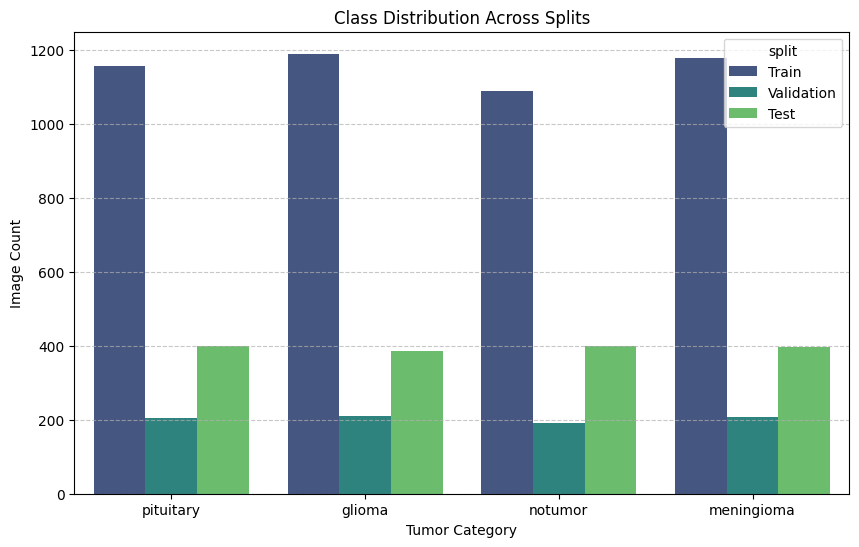

split       Test  Train  Validation  Total
label                                     
glioma       386   1190         210   1786
meningioma   398   1178         208   1784
notumor      400   1089         192   1681
pituitary    400   1157         205   1762


In [3]:
os.makedirs('results', exist_ok=True)

# Class count plot
plt.figure(figsize=(10, 6))
sns.countplot(data=full_df, x='label', hue='split', palette='viridis')
plt.title('Class Distribution Across Splits')
plt.xlabel('Tumor Category')
plt.ylabel('Image Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('results/class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

# Table of distributions
dist_table = full_df.groupby(['label', 'split']).size().unstack(fill_value=0)
dist_table['Total'] = dist_table.sum(axis=1)
print(dist_table)


## 3. Image Dimension Analysis
We analyze image dimensions to see the variation in resolutions across scans.

Minimum resolution (width, height): (150, 183)
Maximum resolution (width, height): (1024, 872)
Mean resolution (width, height): (467.8, 471.7)


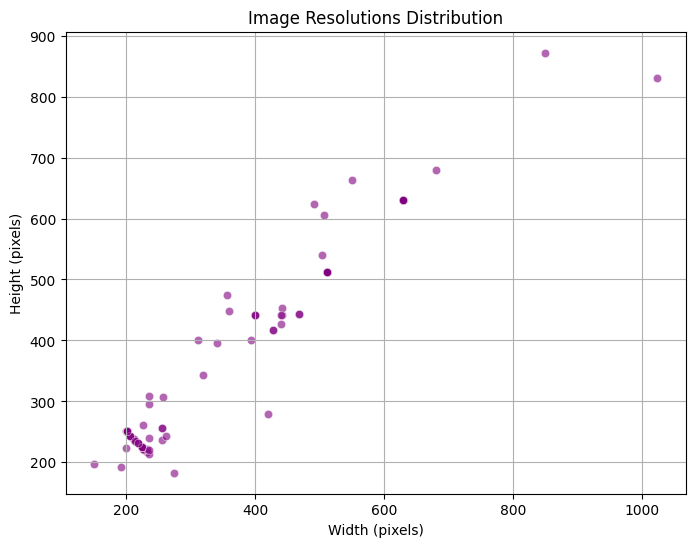

In [4]:
resolutions = []
# Sample up to 300 images to inspect shape
for idx, row in full_df.sample(min(300, len(full_df)), random_state=42).iterrows():
    try:
        with Image.open(row['filepath']) as img:
            w, h = img.size
            resolutions.append((w, h))
    except Exception:
        pass

resolutions = np.array(resolutions)
print(f"Minimum resolution (width, height): ({resolutions[:,0].min()}, {resolutions[:,1].min()})")
print(f"Maximum resolution (width, height): ({resolutions[:,0].max()}, {resolutions[:,1].max()})")
print(f"Mean resolution (width, height): ({resolutions[:,0].mean():.1f}, {resolutions[:,1].mean():.1f})")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=resolutions[:,0], y=resolutions[:,1], alpha=0.6, color='purple')
plt.title('Image Resolutions Distribution')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.grid(True)
plt.savefig('results/resolution_scatter.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. Visualize Sample MRI Scans
We plot a grid of sample images from each tumor category to understand the visual differences.

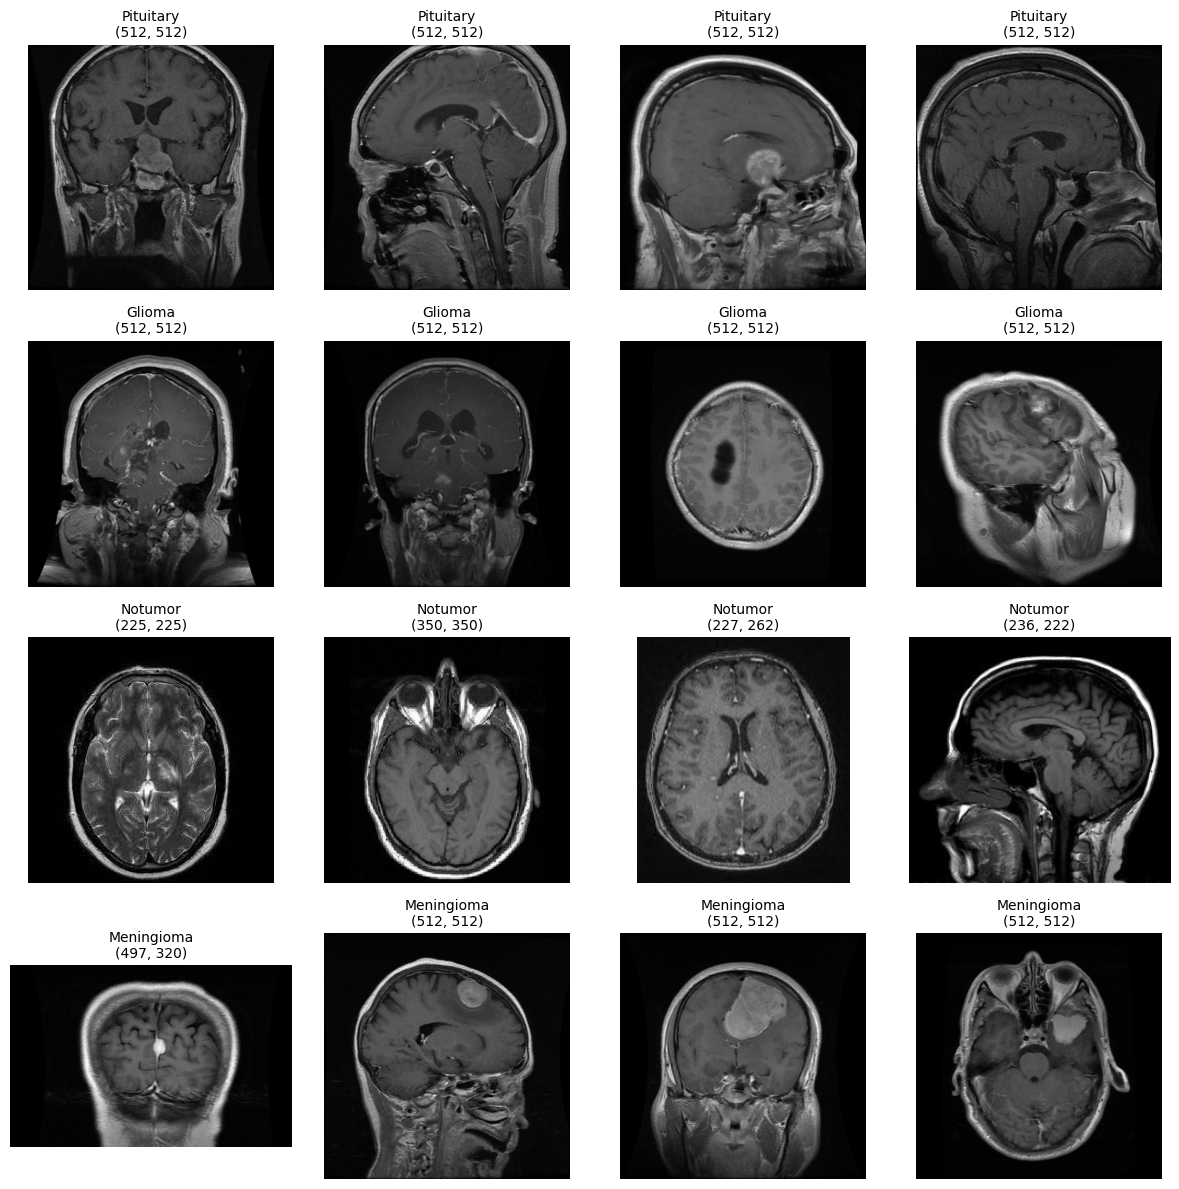

In [5]:
classes = full_df['label'].unique()
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i, cls in enumerate(classes):
    cls_df = full_df[full_df['label'] == cls]
    samples = cls_df.sample(4, random_state=42)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row['filepath'])
        ax = axes[i, j]
        ax.imshow(img, cmap='gray' if len(img.getbands()) == 1 else None)
        ax.set_title(f"{row['label'].capitalize()}\n{img.size}", fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.savefig('results/sample_images.png', bbox_inches='tight', dpi=150)
plt.show()


## 5. Average Intensity Heatmaps
We compute the average image intensity profile for each class. This shows whether there are class-specific location or size biases in the MRI slices.

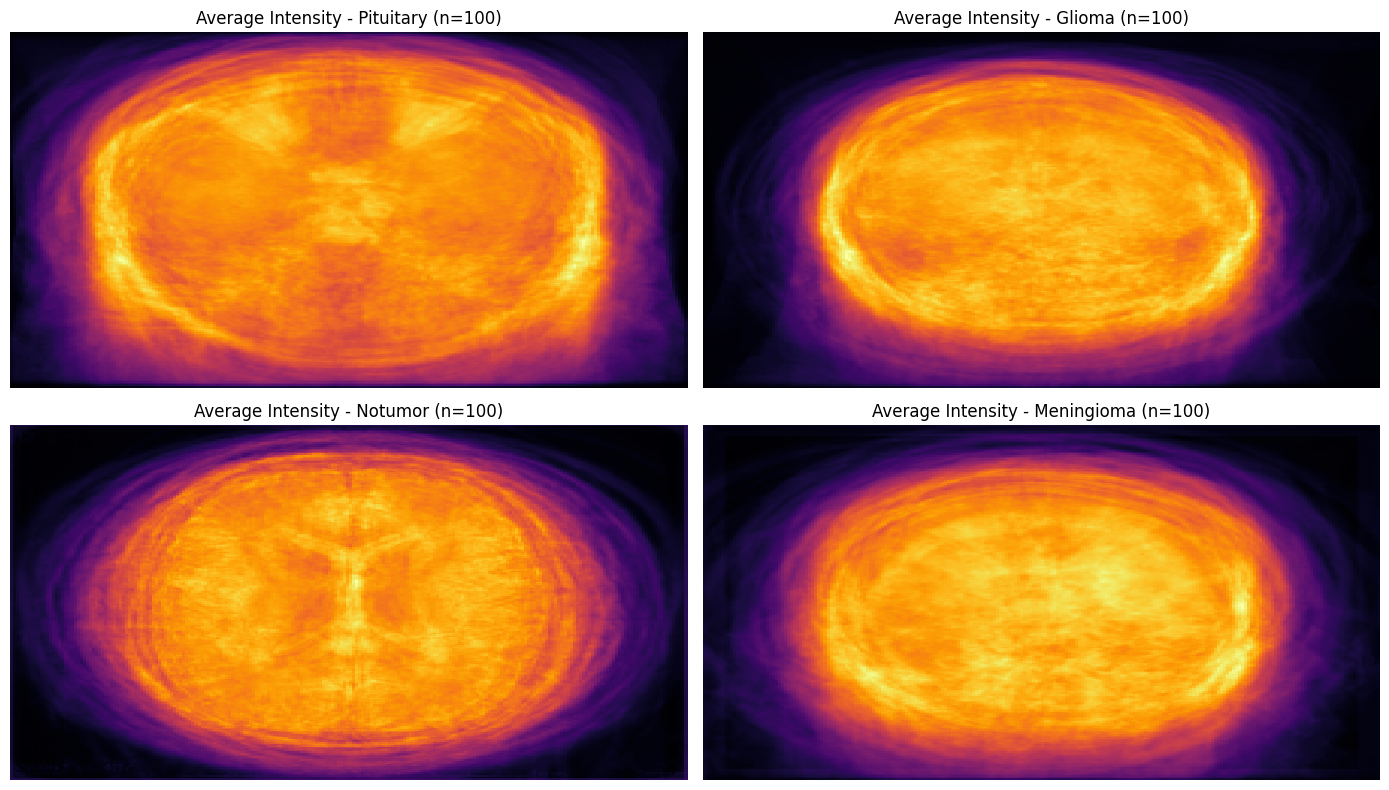

In [6]:
plt.figure(figsize=(14, 8))
for i, cls in enumerate(classes):
    cls_df = full_df[full_df['label'] == cls]
    avg_img = np.zeros((224, 224), dtype=np.float32)
    count = 0
    
    # Average over 100 samples per class
    for _, row in cls_df.sample(min(100, len(cls_df)), random_state=42).iterrows():
        img = cv2.imread(row['filepath'], cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img_res = cv2.resize(img, (224, 224))
            avg_img += img_res / 255.0
            count += 1
            
    if count > 0:
        avg_img /= count
        
    plt.subplot(2, 2, i+1)
    sns.heatmap(avg_img, cmap='inferno', cbar=False)
    plt.title(f"Average Intensity - {cls.capitalize()} (n={count})")
    plt.axis('off')

plt.tight_layout()
plt.savefig('results/average_intensity_maps.png', bbox_inches='tight', dpi=150)
plt.show()
